In [3]:
import numpy as np

class GridWorld:
    def __init__(self, stochastic=False):
        self.rows, self.cols = 3, 4
        self.wall = (1, 1)
        self.terminals = {(0, 3): 1, (1, 3): -1}
        self.actions = ["U", "D", "L", "R"]
        self.gamma = 0.9
        self.step = 0

        # Stochastic attributes
        self.stochastic = stochastic
        self.p_intended = 0.8
        self.p_side = 0.1

    def is_terminal(self, s):
        return s in self.terminals

    def move(self, s, a):
        if self.is_terminal(s):
            return s

        r, c = s

        if a == "U":
            r -= 1
        elif a == "D":
            r += 1
        elif a == "L":
            c -= 1
        elif a == "R":
            c += 1

        ns = (r, c)

        if (r < 0 or r >= self.rows or c < 0 or c >= self.cols or ns == self.wall):
            return s

        return ns

    def get_side_actions(self, a):
        """Returns the two side actions for a given action (for stochastic environment)"""
        if a == "U":
            return ("L", "R")
        if a == "D":
            return ("R", "L")
        if a == "L":
            return ("D", "U")
        if a == "R":
            return ("U", "D")

    def expected_value(self, V, s, a):
        """Calculate expected value for stochastic environment"""
        if not self.stochastic:
            # Deterministic case
            ns = self.move(s, a)
            if self.is_terminal(ns):
                return self.step + self.gamma * self.terminals[ns]
            else:
                nr, nc = ns
                return self.step + self.gamma * V[nr, nc]
        else:
            # Stochastic case
            left, right = self.get_side_actions(a)
            transitions = [
                (self.p_intended, a),
                (self.p_side, left),
                (self.p_side, right),
            ]

            value = 0
            for p, act in transitions:
                ns = self.move(s, act)
                if self.is_terminal(ns):
                    reward = self.terminals[ns]
                    value += p * (self.step + self.gamma * reward)
                else:
                    nr, nc = ns
                    value += p * (self.step + self.gamma * V[nr, nc])

            return value


def value_iteration(env, theta=1e-5):
    V = np.zeros((env.rows, env.cols))

    while True:
        delta = 0
        V_old = V.copy()

        for r in range(env.rows):
            for c in range(env.cols):
                s = (r, c)

                if s == env.wall:
                    continue

                if env.is_terminal(s):
                    V[r, c] = env.terminals[s]
                    continue

                values = []
                for a in env.actions:
                    v = env.expected_value(V_old, s, a)
                    values.append(v)

                new_v = max(values)
                delta = max(delta, abs(new_v - V[r, c]))
                V[r, c] = new_v

        if delta < theta:
            break

    return V


def extract_policy(env, V):
    policy = np.full((env.rows, env.cols), "", dtype=object)

    for r in range(env.rows):
        for c in range(env.cols):
            s = (r, c)

            if s == env.wall:
                policy[r, c] = "#"
                continue

            if env.is_terminal(s):
                policy[r, c] = "T"
                continue

            best_a = None
            best_v = -1e9

            for a in env.actions:
                v = env.expected_value(V, s, a)
                if v > best_v:
                    best_v = v
                    best_a = a

            policy[r, c] = best_a

    return policy


# Test both environments
print("=" * 50)
print("DETERMINISTIC ENVIRONMENT")
print("=" * 50)
env_det = GridWorld(stochastic=False)
V_det = value_iteration(env_det)
policy_det = extract_policy(env_det, V_det)

np.set_printoptions(precision=3, suppress=True)
print("Value Function:\n", V_det)
print("\nPolicy:\n", policy_det)

print("\n" + "=" * 50)
print("STOCHASTIC ENVIRONMENT")
print("=" * 50)
env_stoch = GridWorld(stochastic=True)
V_stoch = value_iteration(env_stoch)
policy_stoch = extract_policy(env_stoch, V_stoch)

print("Value Function:\n", V_stoch)
print("\nPolicy:\n", policy_stoch)

DETERMINISTIC ENVIRONMENT
Value Function:
 [[ 0.729  0.81   0.9    1.   ]
 [ 0.656  0.     0.81  -1.   ]
 [ 0.59   0.656  0.729  0.656]]

Policy:
 [['R' 'R' 'R' 'T']
 ['U' '#' 'U' 'T']
 ['U' 'R' 'U' 'L']]

STOCHASTIC ENVIRONMENT
Value Function:
 [[ 0.645  0.744  0.848  1.   ]
 [ 0.566  0.     0.572 -1.   ]
 [ 0.491  0.431  0.475  0.277]]

Policy:
 [['R' 'R' 'R' 'T']
 ['U' '#' 'U' 'T']
 ['U' 'L' 'U' 'L']]


Running value iteration for deterministic environment...
Running value iteration for stochastic environment...

DETERMINISTIC ENVIRONMENT
Grid Size: 3 x 4
Wall at: (1, 1)
Terminal states: {(0, 3): 1, (1, 3): -1}
Discount factor (γ): 0.9

Value Function:
------------------------------
|   0.729 |   0.810 |   0.900 |   1.000 | 
|   0.656 |   WALL  |   0.810 |  -1.000 | 
|   0.590 |   0.656 |   0.729 |   0.656 | 

Optimal Policy:
------------------------------
|    R    |    R    |    R    |   TERM+  | 
|    U    |   WALL  |    U    |   TERM-  | 
|    U    |    R    |    U    |    L    | 

STOCHASTIC ENVIRONMENT
Grid Size: 3 x 4
Wall at: (1, 1)
Terminal states: {(0, 3): 1, (1, 3): -1}
Discount factor (γ): 0.9
Action success probability: 0.8
Action side probability: 0.1 each

Value Function:
------------------------------
|   0.645 |   0.744 |   0.848 |   1.000 | 
|   0.566 |   WALL  |   0.572 |  -1.000 | 
|   0.491 |   0.431 |   0.475 |   0.277 | 

Optimal Policy:
------------------------

/tmp/ipykernel_536/1015812337.py:241: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_536/1015812337.py:241: UserWarning: Glyph 129521 (\N{BRICK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_536/1015812337.py:241: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_536/1015812337.py:241: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_536/1015812337.py:241: UserWarning: Glyph 129521 (\N{BRICK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_536/1015812337.py:241: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12

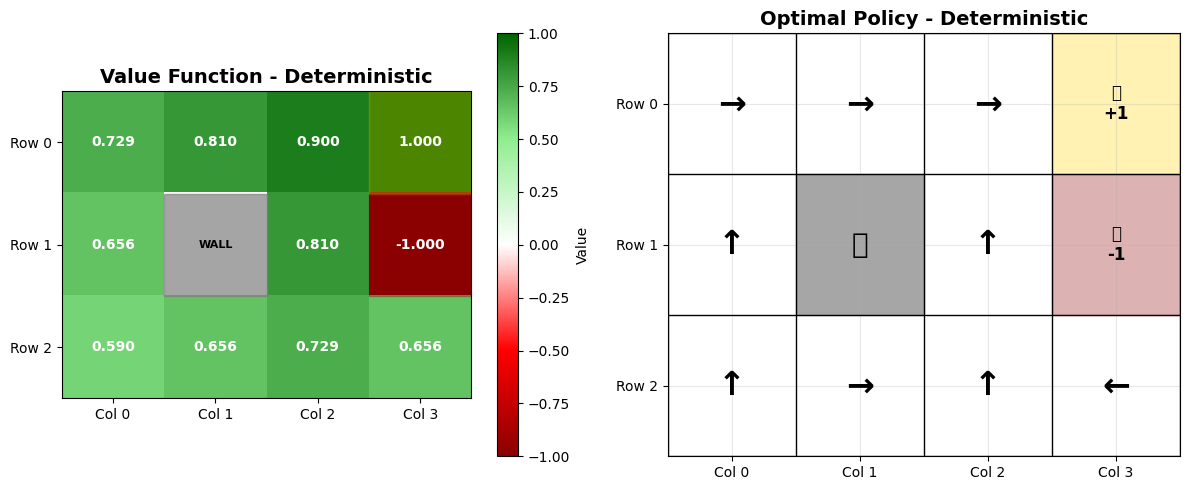

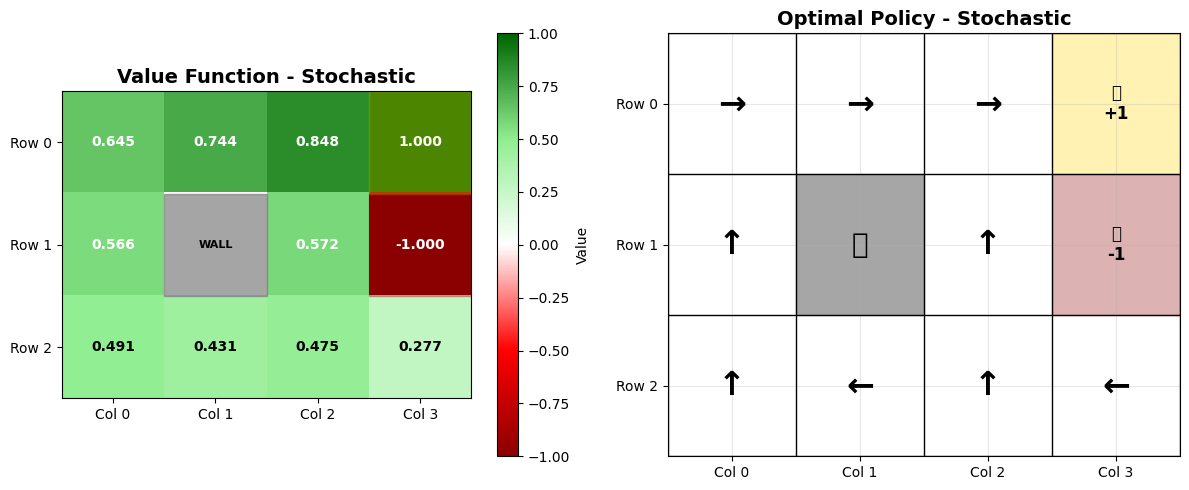


KEY DIFFERENCES

Value Function Comparison:
----------------------------------------
State (0,0): Det=0.729, Stoch=0.645, Diff=+0.084
State (0,1): Det=0.810, Stoch=0.744, Diff=+0.066
State (0,2): Det=0.900, Stoch=0.848, Diff=+0.052
State (1,0): Det=0.656, Stoch=0.566, Diff=+0.090
State (1,2): Det=0.810, Stoch=0.572, Diff=+0.238
State (2,0): Det=0.590, Stoch=0.491, Diff=+0.100
State (2,1): Det=0.656, Stoch=0.431, Diff=+0.225
State (2,2): Det=0.729, Stoch=0.475, Diff=+0.254
State (2,3): Det=0.656, Stoch=0.277, Diff=+0.379

Policy Differences:
----------------------------------------
State (2,1): Det=R, Stoch=L

Found 1 state(s) with different policies


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

class GridWorld:
    def __init__(self, stochastic=False):
        self.rows, self.cols = 3, 4
        self.wall = (1, 1)
        self.terminals = {(0, 3): 1, (1, 3): -1}
        self.actions = ["U", "D", "L", "R"]
        self.action_symbols = {"U": "↑", "D": "↓", "L": "←", "R": "→"}
        self.gamma = 0.9
        self.step = 0

        # Stochastic attributes
        self.stochastic = stochastic
        self.p_intended = 0.8
        self.p_side = 0.1

    def is_terminal(self, s):
        return s in self.terminals

    def move(self, s, a):
        if self.is_terminal(s):
            return s

        r, c = s

        if a == "U":
            r -= 1
        elif a == "D":
            r += 1
        elif a == "L":
            c -= 1
        elif a == "R":
            c += 1

        ns = (r, c)

        if (r < 0 or r >= self.rows or c < 0 or c >= self.cols or ns == self.wall):
            return s

        return ns

    def get_side_actions(self, a):
        """Returns the two side actions for a given action (for stochastic environment)"""
        if a == "U":
            return ("L", "R")
        if a == "D":
            return ("R", "L")
        if a == "L":
            return ("D", "U")
        if a == "R":
            return ("U", "D")

    def expected_value(self, V, s, a):
        """Calculate expected value for stochastic environment"""
        if not self.stochastic:
            # Deterministic case
            ns = self.move(s, a)
            if self.is_terminal(ns):
                return self.step + self.gamma * self.terminals[ns]
            else:
                nr, nc = ns
                return self.step + self.gamma * V[nr, nc]
        else:
            # Stochastic case
            left, right = self.get_side_actions(a)
            transitions = [
                (self.p_intended, a),
                (self.p_side, left),
                (self.p_side, right),
            ]

            value = 0
            for p, act in transitions:
                ns = self.move(s, act)
                if self.is_terminal(ns):
                    reward = self.terminals[ns]
                    value += p * (self.step + self.gamma * reward)
                else:
                    nr, nc = ns
                    value += p * (self.step + self.gamma * V[nr, nc])

            return value


def value_iteration(env, theta=1e-5):
    V = np.zeros((env.rows, env.cols))

    while True:
        delta = 0
        V_old = V.copy()

        for r in range(env.rows):
            for c in range(env.cols):
                s = (r, c)

                if s == env.wall:
                    continue

                if env.is_terminal(s):
                    V[r, c] = env.terminals[s]
                    continue

                values = []
                for a in env.actions:
                    v = env.expected_value(V_old, s, a)
                    values.append(v)

                new_v = max(values)
                delta = max(delta, abs(new_v - V[r, c]))
                V[r, c] = new_v

        if delta < theta:
            break

    return V


def extract_policy(env, V):
    policy = np.full((env.rows, env.cols), "", dtype=object)
    policy_symbols = np.full((env.rows, env.cols), "", dtype=object)

    for r in range(env.rows):
        for c in range(env.cols):
            s = (r, c)

            if s == env.wall:
                policy[r, c] = "#"
                policy_symbols[r, c] = "█"
                continue

            if env.is_terminal(s):
                if env.terminals[s] > 0:
                    policy[r, c] = "T+"
                    policy_symbols[r, c] = "🏆"
                else:
                    policy[r, c] = "T-"
                    policy_symbols[r, c] = "💀"
                continue

            best_a = None
            best_v = -1e9

            for a in env.actions:
                v = env.expected_value(V, s, a)
                if v > best_v:
                    best_v = v
                    best_a = a

            policy[r, c] = best_a
            policy_symbols[r, c] = env.action_symbols[best_a]

    return policy, policy_symbols


def visualize_gridworld(env, V, policy_symbols, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Custom colormap for value function (red for negative, white for neutral, green for positive)
    colors = ['darkred', 'red', 'white', 'lightgreen', 'darkgreen']
    cmap = LinearSegmentedColormap.from_list('custom', colors, N=256)

    # Create masks for special cells
    value_display = V.copy()
    wall_mask = np.zeros_like(V, dtype=bool)
    terminal_mask = np.zeros_like(V, dtype=bool)

    for r in range(env.rows):
        for c in range(env.cols):
            if (r, c) == env.wall:
                wall_mask[r, c] = True
            elif (r, c) in env.terminals:
                terminal_mask[r, c] = True

    # Plot 1: Value Function Heatmap
    im = ax1.imshow(value_display, cmap=cmap, vmin=-1, vmax=1, aspect='equal')
    ax1.set_title(f'Value Function - {title}', fontsize=14, fontweight='bold')
    ax1.set_xticks(np.arange(env.cols))
    ax1.set_yticks(np.arange(env.rows))
    ax1.set_xticklabels([f'Col {i}' for i in range(env.cols)])
    ax1.set_yticklabels([f'Row {i}' for i in range(env.rows)])

    # Add value text
    for i in range(env.rows):
        for j in range(env.cols):
            if not wall_mask[i, j]:
                color = 'black' if abs(value_display[i, j]) < 0.5 else 'white'
                ax1.text(j, i, f'{value_display[i, j]:.3f}',
                        ha='center', va='center', fontsize=10, fontweight='bold', color=color)

    # Mark special cells
    for i in range(env.rows):
        for j in range(env.cols):
            if wall_mask[i, j]:
                ax1.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='gray', alpha=0.7))
                ax1.text(j, i, 'WALL', ha='center', va='center', fontsize=8, fontweight='bold')
            elif terminal_mask[i, j]:
                if value_display[i, j] > 0:
                    ax1.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='gold', alpha=0.3))
                else:
                    ax1.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='darkred', alpha=0.3))

    plt.colorbar(im, ax=ax1, label='Value')

    # Plot 2: Policy Visualization
    ax2.set_title(f'Optimal Policy - {title}', fontsize=14, fontweight='bold')
    ax2.set_xlim(-0.5, env.cols - 0.5)
    ax2.set_ylim(env.rows - 0.5, -0.5)
    ax2.set_xticks(np.arange(env.cols))
    ax2.set_yticks(np.arange(env.rows))
    ax2.set_xticklabels([f'Col {i}' for i in range(env.cols)])
    ax2.set_yticklabels([f'Row {i}' for i in range(env.rows)])
    ax2.grid(True, alpha=0.3)

    # Draw grid
    for i in range(env.rows + 1):
        ax2.axhline(y=i - 0.5, color='black', linewidth=1)
    for j in range(env.cols + 1):
        ax2.axvline(x=j - 0.5, color='black', linewidth=1)

    # Add policy symbols
    for i in range(env.rows):
        for j in range(env.cols):
            if (i, j) == env.wall:
                ax2.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='gray', alpha=0.7))
                ax2.text(j, i, '🧱', ha='center', va='center', fontsize=20)
            elif (i, j) in env.terminals:
                if env.terminals[(i, j)] > 0:
                    ax2.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='gold', alpha=0.3))
                    ax2.text(j, i, '🏆\n+1', ha='center', va='center', fontsize=12, fontweight='bold')
                else:
                    ax2.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='darkred', alpha=0.3))
                    ax2.text(j, i, '💀\n-1', ha='center', va='center', fontsize=12, fontweight='bold')
            else:
                ax2.text(j, i, policy_symbols[i, j], ha='center', va='center', fontsize=24, fontweight='bold')

    plt.tight_layout()
    return fig


def visualize_comparison(env_det, V_det, policy_det_symbols, env_stoch, V_stoch, policy_stoch_symbols):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Custom colormap
    colors = ['darkred', 'red', 'white', 'lightgreen', 'darkgreen']
    cmap = LinearSegmentedColormap.from_list('custom', colors, N=256)

    titles = [
        ('Deterministic - Value Function', 'Deterministic - Optimal Policy'),
        ('Stochastic - Value Function', 'Stochastic - Optimal Policy')
    ]

    values = [V_det, V_stoch]
    policies = [policy_det_symbols, policy_stoch_symbols]
    envs = [env_det, env_stoch]

    for row in range(2):
        # Value function
        ax = axes[row, 0]
        im = ax.imshow(values[row], cmap=cmap, vmin=-1, vmax=1, aspect='equal')
        ax.set_title(titles[row][0], fontsize=12, fontweight='bold')
        ax.set_xticks(np.arange(envs[row].cols))
        ax.set_yticks(np.arange(envs[row].rows))
        ax.set_xticklabels([f'C{j}' for j in range(envs[row].cols)])
        ax.set_yticklabels([f'R{i}' for i in range(envs[row].rows)])

        # Add value text
        for i in range(envs[row].rows):
            for j in range(envs[row].cols):
                if (i, j) != envs[row].wall:
                    color = 'black' if abs(values[row][i, j]) < 0.5 else 'white'
                    ax.text(j, i, f'{values[row][i, j]:.2f}',
                           ha='center', va='center', fontsize=9, fontweight='bold', color=color)

        # Mark wall
        if envs[row].wall:
            i, j = envs[row].wall
            ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='gray', alpha=0.7))
            ax.text(j, i, 'WALL', ha='center', va='center', fontsize=8, fontweight='bold')

        # Policy
        ax = axes[row, 1]
        ax.set_title(titles[row][1], fontsize=12, fontweight='bold')
        ax.set_xlim(-0.5, envs[row].cols - 0.5)
        ax.set_ylim(envs[row].rows - 0.5, -0.5)
        ax.set_xticks(np.arange(envs[row].cols))
        ax.set_yticks(np.arange(envs[row].rows))
        ax.set_xticklabels([f'C{j}' for j in range(envs[row].cols)])
        ax.set_yticklabels([f'R{i}' for i in range(envs[row].rows)])
        ax.grid(True, alpha=0.3)

        # Draw grid
        for i in range(envs[row].rows + 1):
            ax.axhline(y=i - 0.5, color='black', linewidth=1)
        for j in range(envs[row].cols + 1):
            ax.axvline(x=j - 0.5, color='black', linewidth=1)

        # Add policy symbols
        for i in range(envs[row].rows):
            for j in range(envs[row].cols):
                if (i, j) == envs[row].wall:
                    ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='gray', alpha=0.7))
                    ax.text(j, i, '🧱', ha='center', va='center', fontsize=16)
                elif (i, j) in envs[row].terminals:
                    if envs[row].terminals[(i, j)] > 0:
                        ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='gold', alpha=0.3))
                        ax.text(j, i, '🏆\n+1', ha='center', va='center', fontsize=10, fontweight='bold')
                    else:
                        ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='darkred', alpha=0.3))
                        ax.text(j, i, '💀\n-1', ha='center', va='center', fontsize=10, fontweight='bold')
                else:
                    ax.text(j, i, policies[row][i, j], ha='center', va='center', fontsize=20, fontweight='bold')

    plt.colorbar(im, ax=axes[:, 0], label='Value', location='left')
    plt.tight_layout()
    return fig


def print_environment_info(env, V, policy, title):
    print(f"\n{'='*60}")
    print(f"{title} ENVIRONMENT")
    print(f"{'='*60}")
    print(f"Grid Size: {env.rows} x {env.cols}")
    print(f"Wall at: {env.wall}")
    print(f"Terminal states: {env.terminals}")
    print(f"Discount factor (γ): {env.gamma}")
    if env.stochastic:
        print(f"Action success probability: {env.p_intended}")
        print(f"Action side probability: {env.p_side} each")

    print("\nValue Function:")
    print("-" * 30)
    for i in range(env.rows):
        row_str = "| "
        for j in range(env.cols):
            if (i, j) == env.wall:
                row_str += "  WALL  | "
            else:
                row_str += f"{V[i, j]:7.3f} | "
        print(row_str)

    print("\nOptimal Policy:")
    print("-" * 30)
    for i in range(env.rows):
        row_str = "| "
        for j in range(env.cols):
            if (i, j) == env.wall:
                row_str += "  WALL  | "
            elif (i, j) in env.terminals:
                val = env.terminals[(i, j)]
                row_str += f"  TERM{'+' if val>0 else '-'}  | "
            else:
                row_str += f"   {policy[i][j]}    | "
        print(row_str)


# Main execution
if __name__ == "__main__":
    # Create environments
    env_det = GridWorld(stochastic=False)
    env_stoch = GridWorld(stochastic=True)

    # Run value iteration
    print("Running value iteration for deterministic environment...")
    V_det = value_iteration(env_det)
    policy_det, policy_det_symbols = extract_policy(env_det, V_det)

    print("Running value iteration for stochastic environment...")
    V_stoch = value_iteration(env_stoch)
    policy_stoch, policy_stoch_symbols = extract_policy(env_stoch, V_stoch)

    # Print detailed information
    print_environment_info(env_det, V_det, policy_det, "DETERMINISTIC")
    print_environment_info(env_stoch, V_stoch, policy_stoch, "STOCHASTIC")

    # Create visualizations
    print("\n\nCreating visualizations...")

    # Individual visualizations
    fig1 = visualize_gridworld(env_det, V_det, policy_det_symbols, "Deterministic")
    fig2 = visualize_gridworld(env_stoch, V_stoch, policy_stoch_symbols, "Stochastic")


    plt.show()

    # Print key differences
    print("\n" + "="*60)
    print("KEY DIFFERENCES")
    print("="*60)
    print("\nValue Function Comparison:")
    print("-" * 40)
    for i in range(env_det.rows):
        for j in range(env_det.cols):
            if (i, j) != env_det.wall and (i, j) not in env_det.terminals:
                diff = V_det[i, j] - V_stoch[i, j]
                print(f"State ({i},{j}): Det={V_det[i, j]:.3f}, Stoch={V_stoch[i, j]:.3f}, Diff={diff:+.3f}")

    print("\nPolicy Differences:")
    print("-" * 40)
    diff_count = 0
    for i in range(env_det.rows):
        for j in range(env_det.cols):
            if ((i, j) != env_det.wall and
                (i, j) not in env_det.terminals and
                policy_det[i][j] != policy_stoch[i][j]):
                print(f"State ({i},{j}): Det={policy_det[i][j]}, Stoch={policy_stoch[i][j]}")
                diff_count += 1

    if diff_count == 0:
        print("Policies are identical!")
    else:
        print(f"\nFound {diff_count} state(s) with different policies")